In [4]:
# import os

# dataset_path = "../data/raw"

# print(os.path.exists(dataset_path))
# print(os.listdir(dataset_path))




In [6]:
import os
import cv2
import yaml
import random
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [7]:
dataset_path = "../data/raw"

train_img = os.path.join(dataset_path, "train/images")
train_lbl = os.path.join(dataset_path, "train/labels")

valid_img = os.path.join(dataset_path, "valid/images")
valid_lbl = os.path.join(dataset_path, "valid/labels")

test_img = os.path.join(dataset_path, "test/images")
test_lbl = os.path.join(dataset_path, "test/labels")

In [8]:
print("Training Images :", len(os.listdir(train_img)))
print("Validation Images :", len(os.listdir(valid_img)))
print("Testing Images :", len(os.listdir(test_img)))

Training Images : 13605
Validation Images : 1748
Testing Images : 1717


In [11]:
# from collections import Counter
# import pandas as pd
# import os

# counter = Counter()

# for file in os.listdir(train_lbl):
#     if file.endswith(".txt"):
#         with open(os.path.join(train_lbl, file), "r") as f:
#             for line in f:
#                 if line.strip():  # Skip empty lines
#                     cls = int(line.split()[0])
#                     counter[classes[cls]] += 1

# df = pd.DataFrame(
#     counter.items(),
#     columns=["Class", "Count"]
# ).sort_values("Count", ascending=False)

# print(df)
# df

In [13]:
print("Train Images:", train_img)
print("Exists:", os.path.exists(train_img))

print("Train Labels:", train_lbl)
print("Exists:", os.path.exists(train_lbl))

print("Number of label files:", len(os.listdir(train_lbl)))

Train Images: ../data/raw\train/images
Exists: True
Train Labels: ../data/raw\train/labels
Exists: True
Number of label files: 13605


In [14]:
import yaml

with open(os.path.join(dataset_path, "data.yaml")) as f:
    data = yaml.safe_load(f)

classes = list(data["names"].values())

print(classes)
print(len(classes))

['Zebra', 'Lion', 'Leopard', 'Cheetah', 'Tiger', 'Bear', 'Butterfly', 'Canary', 'Crocodile', 'Bull', 'Camel', 'Centipede', 'Caterpillar', 'Duck', 'Squirrel', 'Spider', 'Ladybug', 'Elephant', 'Horse', 'Fox', 'Tortoise', 'Frog', 'Kangaroo', 'Deer', 'Eagle', 'Monkey', 'Snake', 'Owl', 'Swan', 'Goat', 'Rabbit', 'Giraffe', 'Goose', 'PolarBear', 'Raven', 'Hippopotamus', 'BrownBear', 'Rhinoceros', 'Woodpecker', 'Sheep', 'Magpie', 'Ostrich', 'Jaguar', 'Hedgehog', 'Turkey', 'Raccoon', 'Worm', 'Harbor', 'Panda', 'RedPanda', 'Otter', 'Lynx', 'Scorpion', 'Koala']
54


In [18]:
from collections import Counter
import pandas as pd
import os

counter = Counter()

for file in os.listdir(train_lbl):
    if file.endswith(".txt"):
        with open(os.path.join(train_lbl, file), "r") as f:
            for line in f:
                if line.strip():  # Skip empty lines
                    cls = int(line.split()[0])
                    counter[classes[cls]] += 1

df = pd.DataFrame(
    counter.items(),
    columns=["Class", "Count"]
).sort_values("Count", ascending=False)

print(df)

           Class  Count
2      Butterfly   2259
11        Monkey    976
1         Spider    867
10         Eagle    750
22          Duck    677
12         Snake    639
7           Frog    527
5          Horse    527
9           Deer    516
31      Tortoise    432
20   Caterpillar    424
13           Owl    404
3        Ladybug    364
0       Squirrel    350
14          Swan    300
16         Tiger    295
23       Giraffe    293
19         Goose    281
39        Rabbit    273
21     PolarBear    243
15          Lion    243
28    Rhinoceros    240
17          Goat    234
25         Zebra    210
38       Ostrich    198
6            Fox    186
33         Sheep    184
30    Woodpecker    179
18     Centipede    172
4       Elephant    164
37       Leopard    151
26     Crocodile    143
40         Raven    139
8       Kangaroo    130
43       Raccoon    130
27     BrownBear    129
44          Worm    115
41        Turkey    115
36      Hedgehog    106
51      Scorpion    104
46        Harbor

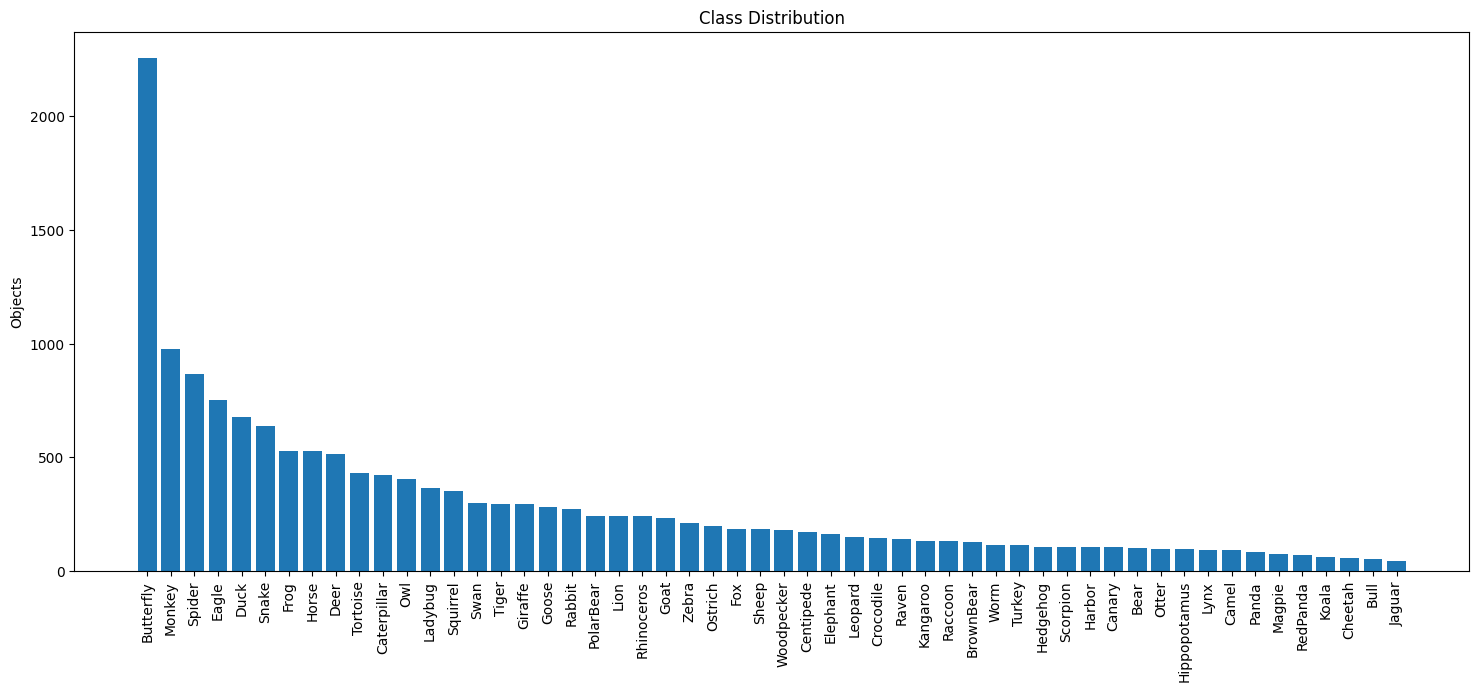

In [19]:
plt.figure(figsize=(18,7))

plt.bar(df["Class"], df["Count"])

plt.xticks(rotation=90)

plt.title("Class Distribution")

plt.ylabel("Objects")

plt.show()

In [20]:
width = []
height = []

for file in os.listdir(train_img):

    img = cv2.imread(os.path.join(train_img, file))

    h,w = img.shape[:2]

    width.append(w)

    height.append(h)

print("Average Width :", sum(width)/len(width))
print("Average Height :", sum(height)/len(height))

Average Width : 986.5851525174568
Average Height : 777.188901139287


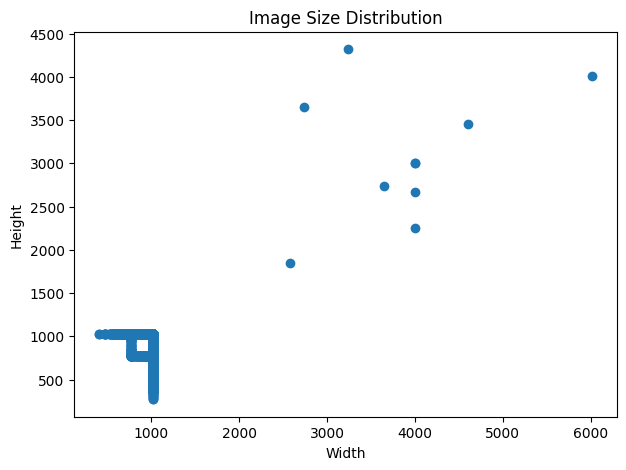

In [21]:
plt.figure(figsize=(7,5))

plt.scatter(width,height)

plt.xlabel("Width")

plt.ylabel("Height")

plt.title("Image Size Distribution")

plt.show()

In [22]:
bbox_width = []

bbox_height = []

for file in os.listdir(train_lbl):

    with open(os.path.join(train_lbl,file)) as f:

        for line in f:

            _,x,y,w,h = map(float,line.split())

            bbox_width.append(w)

            bbox_height.append(h)

print("Total Bounding Boxes :", len(bbox_width))

Total Bounding Boxes : 15791


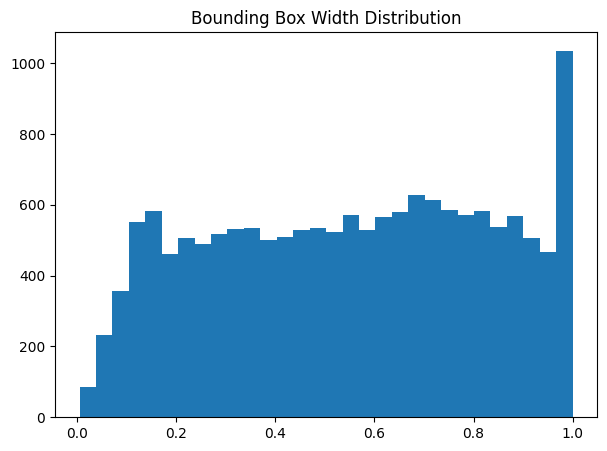

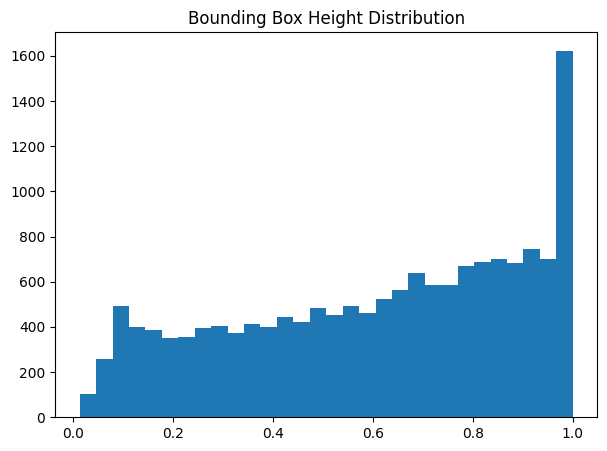

In [23]:
plt.figure(figsize=(7,5))

plt.hist(bbox_width,bins=30)

plt.title("Bounding Box Width Distribution")

plt.show()

plt.figure(figsize=(7,5))

plt.hist(bbox_height,bins=30)

plt.title("Bounding Box Height Distribution")

plt.show()

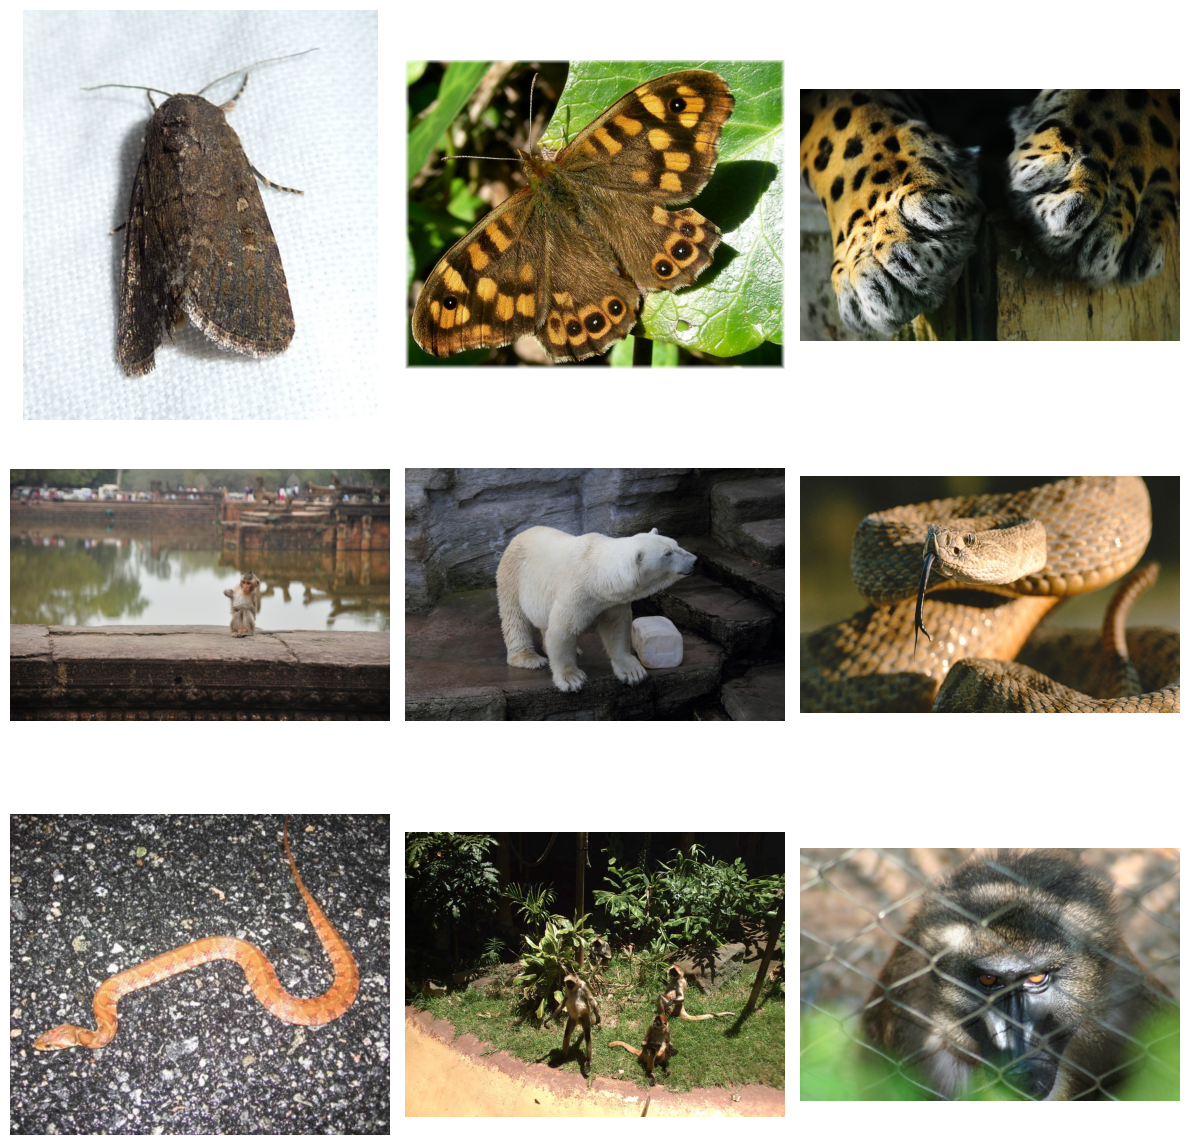

In [24]:
images = random.sample(os.listdir(train_img),9)

plt.figure(figsize=(12,12))

for i,img_name in enumerate(images):

    img = cv2.imread(os.path.join(train_img,img_name))

    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [26]:
def draw_boxes(image_path,label_path):

    img = cv2.imread(image_path)

    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    h,w = img.shape[:2]

    with open(label_path) as f:

        for line in f:

            cls,x,y,bw,bh = map(float,line.split())

            x1 = int((x-bw/2)*w)

            y1 = int((y-bh/2)*h)

            x2 = int((x+bw/2)*w)

            y2 = int((y+bh/2)*h)

            cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),2)

            cv2.putText(img,
                        classes[int(cls)],
                        (x1,y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        (255,0,0),
                        2)

    return img

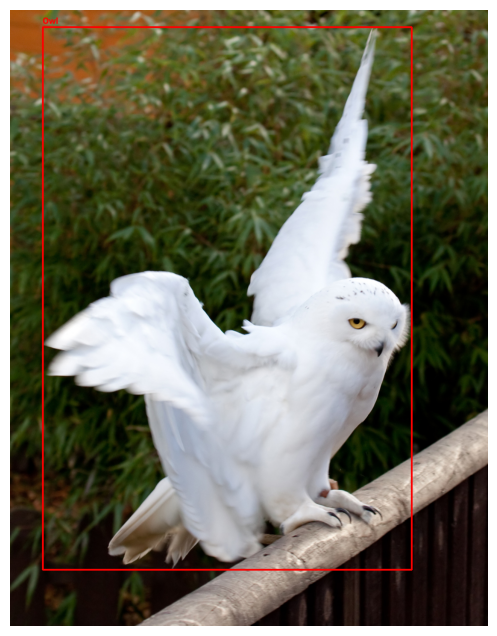

In [27]:
sample = random.choice(os.listdir(train_img))

image = draw_boxes(
    os.path.join(train_img,sample),
    os.path.join(train_lbl,sample.replace(".jpg",".txt"))
)

plt.figure(figsize=(8,8))

plt.imshow(image)

plt.axis("off")

plt.show()

In [28]:
df.head(10)


,Class,Count
2,Butterfly,2259
11,Monkey,976
1,Spider,867
10,Eagle,750
22,Duck,677
12,Snake,639
7,Frog,527
5,Horse,527
9,Deer,516
31,Tortoise,432


In [29]:
df.tail(10)

,Class,Count
24,Hippopotamus,95
50,Lynx,91
45,Camel,90
47,Panda,83
32,Magpie,75
48,RedPanda,71
52,Koala,59
53,Cheetah,58
35,Bull,51
34,Jaguar,43
